Total beacon records: 2528
Time range: 8.07 .. 215.60 s

 [1] TEMPERATURE COLUMN CHECK
  p1_temp: n=2247, min=29.90, max=42.10, range=12.20, unique=25
    first 5 values: [29.9 33.1 29.9 33.1 30.9]
    last  5 values: [41.8 41.8 42.1 41.8 41.8]
  p2_temp: n=1753, min=40.90, max=183.60, range=142.70, unique=15
    first 5 values: [40.9 40.9 40.9 40.9 40.9]
    last  5 values: [46.9 47.1 41.9 46.9 47.1]

 [2] SAR COLUMN CHECK
  p1_sar: unique values = [0, 255]
  p2_sar: unique values = [0, 255]

Total valid link measurements after filter: 3997

 [4] LINK CONNECTION TIMELINE
  link |    n |  t_first_s |   t_last_s | duration_s |   gap%
--------------------------------------------------------------
  2->3 |  569 |      77.08 |     215.48 |     138.40 |    1.4
  2->4 |  583 |      73.67 |     215.48 |     141.81 |    1.4
  3->2 |  606 |      68.12 |     215.54 |     147.42 |    1.4
  3->4 |  828 |      12.97 |     215.54 |     202.57 |    2.0
  4->2 |  583 |      73.79 |     215.60 |     14

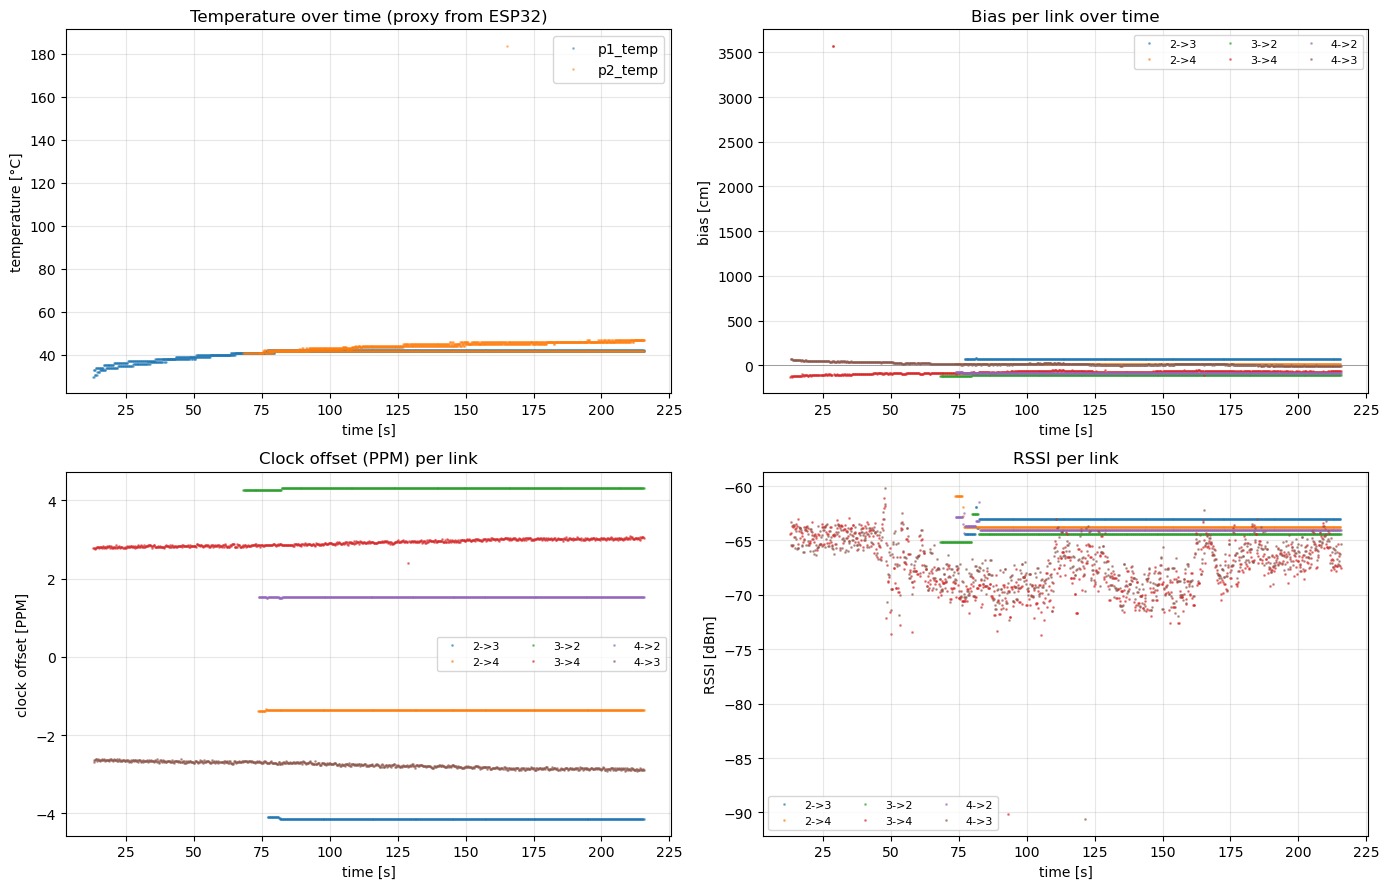

In [2]:
# ============================================================
# Gateway analysis — CFO compensation + proxy temperature
# ============================================================
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 320)
np.set_printoptions(precision=4, suppress=True)

# ------------------------------------------------------------
# 0. Load
# ------------------------------------------------------------
FILE = "third_test.csv"

rows = []
with open(FILE, "r") as f:
    for line in f:
        line = line.strip()
        if not line or line.startswith("#"):
            continue
        rows.append(line)

header = rows[0].split(",")
df = pd.DataFrame([r.split(",") for r in rows[1:]], columns=header)
for c in df.columns:
    df[c] = pd.to_numeric(df[c], errors="coerce")

print(f"Total beacon records: {len(df)}")
print(f"Time range: {df['rx_ms'].iloc[0]/1000:.2f} .. "
      f"{df['rx_ms'].iloc[-1]/1000:.2f} s")

# ------------------------------------------------------------
# 1. Sanity check: temperature column
# ------------------------------------------------------------
print("\n" + "=" * 96)
print(" [1] TEMPERATURE COLUMN CHECK")
print("=" * 96)
for slot in (1, 2):
    tcol = f"p{slot}_temp"
    if tcol not in df.columns: continue
    tv = df[tcol].values
    tv = tv[tv > 0]  # exclude empty
    if len(tv) < 5: continue
    print(f"  {tcol}: n={len(tv)}, "
          f"min={tv.min():.2f}, max={tv.max():.2f}, "
          f"range={tv.max()-tv.min():.2f}, "
          f"unique={len(np.unique(np.round(tv, 2)))}")
    print(f"    first 5 values: {tv[:5]}")
    print(f"    last  5 values: {tv[-5:]}")

# ------------------------------------------------------------
# 2. SAR still zero?
# ------------------------------------------------------------
print("\n" + "=" * 96)
print(" [2] SAR COLUMN CHECK")
print("=" * 96)
for slot in (1, 2):
    sc = f"p{slot}_sar"
    if sc not in df.columns: continue
    sv = df[sc].values
    print(f"  {sc}: unique values = {sorted(np.unique(sv))[:10]}")

# ------------------------------------------------------------
# 3. Expand to link records (with outlier rejection)
# ------------------------------------------------------------
UWB_RAW_MIN, UWB_RAW_MAX     = 0.0, 200.0
UWB_CLEAN_MIN, UWB_CLEAN_MAX = -5.0, 50.0

link_records = []
for _, row in df.iterrows():
    sender = int(row["senderId"])
    for slot in (1, 2):
        pid = int(row[f"p{slot}_id"])
        if pid == 0: continue
        raw = row[f"p{slot}_raw"]
        clean = row[f"p{slot}_clean"]
        if abs(raw) < 1e-6: continue
        if not (UWB_RAW_MIN < raw < UWB_RAW_MAX): continue
        if not (UWB_CLEAN_MIN < clean < UWB_CLEAN_MAX): continue
        link_records.append({
            "rx_ms":   row["rx_ms"],
            "sender":  sender,
            "peer":    pid,
            "frame":   int(row["frameId"]),
            "uptime":  row["uptimeMs"],
            "raw":     raw,
            "clean":   clean,
            "rssi":    row[f"p{slot}_rssi"],
            "fp":      row[f"p{slot}_fp"],
            "temp":    row[f"p{slot}_temp"],
            "sar":     row[f"p{slot}_sar"],
            "ppm":     row[f"p{slot}_ppm"],
        })

links = pd.DataFrame(link_records)
links["link"] = links["sender"].astype(str) + "->" + links["peer"].astype(str)
links["t_s"]  = links["rx_ms"] / 1000.0
print(f"\nTotal valid link measurements after filter: {len(links)}")

GT_DIST = {
    "2->3": 2.000, "3->2": 2.000,
    "3->4": 2.000, "4->3": 2.000,
    "2->4": 2.828, "4->2": 2.828,
}

# ------------------------------------------------------------
# 4. First/last appearance per link (delayed connection detection)
# ------------------------------------------------------------
print("\n" + "=" * 96)
print(" [4] LINK CONNECTION TIMELINE")
print("=" * 96)
print(f"{'link':>6s} | {'n':>4s} | {'t_first_s':>10s} | "
      f"{'t_last_s':>10s} | {'duration_s':>10s} | {'gap%':>6s}")
print("-" * 62)

for lk, grp in links.groupby("link"):
    t_first = grp["t_s"].min()
    t_last  = grp["t_s"].max()
    duration = t_last - t_first
    # Expected measurements: duration * 4.17
    expected = duration * 4.17
    gap_pct = 100 * (1 - len(grp) / expected) if expected > 0 else 0
    print(f"{lk:>6s} | {len(grp):>4d} | {t_first:>10.2f} | "
          f"{t_last:>10.2f} | {duration:>10.2f} | {gap_pct:>6.1f}")

# ------------------------------------------------------------
# 5. PPM statistics per link
# ------------------------------------------------------------
print("\n" + "=" * 96)
print(" [5] CLOCK OFFSET (PPM) PER LINK")
print("=" * 96)
print(f"{'link':>6s} | {'n':>4s} | {'mean':>9s} | {'std':>8s} | "
      f"{'min':>9s} | {'max':>9s}")
print("-" * 60)
for lk, grp in links.groupby("link"):
    ppm = grp["ppm"].values
    print(f"{lk:>6s} | {len(grp):>4d} | {ppm.mean():>+9.3f} | "
          f"{ppm.std():>8.3f} | {ppm.min():>+9.3f} | "
          f"{ppm.max():>+9.3f}")

# ------------------------------------------------------------
# 6. Bias vs constant ground truth
# ------------------------------------------------------------
print("\n" + "=" * 96)
print(" [6] BIAS WITH CFO COMPENSATION")
print("=" * 96)
print(f"\n{'link':>6s} | {'n':>4s} | {'GT':>7s} | "
      f"{'bias_mean':>10s} | {'bias_std':>10s} | "
      f"{'bias_min':>10s} | {'bias_max':>10s}")
print("-" * 82)

bias_summary = {}
for lk, grp in links.groupby("link"):
    if lk not in GT_DIST: continue
    gt = GT_DIST[lk]
    bias = (grp["clean"] - gt) * 100
    bias_summary[lk] = {
        "n": len(grp),
        "bias_mean": bias.mean(),
        "bias_std": bias.std(),
        "bias_min": bias.min(),
        "bias_max": bias.max(),
    }
    print(f"{lk:>6s} | {len(grp):>4d} | {gt:>7.3f} | "
          f"{bias.mean():>+10.2f} | {bias.std():>10.2f} | "
          f"{bias.min():>+10.2f} | {bias.max():>+10.2f}")
print("  (bias in cm)")

# ------------------------------------------------------------
# 7. Link asymmetry AFTER CFO
# ------------------------------------------------------------
print("\n" + "=" * 96)
print(" [7] LINK ASYMMETRY (AFTER CFO COMPENSATION)")
print("=" * 96)
print("  Previous test (without CFO):")
print("    2↔3: 83 cm    3↔4: 98 cm    2↔4: 12 cm")
print(f"\n  Current test (with CFO):")
for a, b in [(2, 3), (3, 4), (2, 4)]:
    fk = f"{a}->{b}"
    rk = f"{b}->{a}"
    if fk not in bias_summary or rk not in bias_summary: continue
    fb = bias_summary[fk]["bias_mean"]
    rb = bias_summary[rk]["bias_mean"]
    print(f"    {a}↔{b}: fwd={fb:+.2f}, rev={rb:+.2f}, |Δ|={abs(fb-rb):.2f} cm")

# ------------------------------------------------------------
# 8. Bias evolution over time
# ------------------------------------------------------------
print("\n" + "=" * 96)
print(" [8] BIAS EVOLUTION OVER TIME (4 windows)")
print("=" * 96)
for lk, grp in links.groupby("link"):
    if lk not in GT_DIST: continue
    if len(grp) < 20: continue
    t = grp["t_s"].values
    b = (grp["clean"].values - GT_DIST[lk]) * 100
    order = np.argsort(t)
    t = t[order]; b = b[order]
    n = len(b); q = n // 4
    w = [b[:q].mean(), b[q:2*q].mean(),
         b[2*q:3*q].mean(), b[3*q:].mean()]
    print(f"  {lk}: W1={w[0]:>+7.2f}  W2={w[1]:>+7.2f}  "
          f"W3={w[2]:>+7.2f}  W4={w[3]:>+7.2f}  "
          f"spread={max(w)-min(w):>6.2f} cm")

# ------------------------------------------------------------
# 9. Correlation bias vs PPM
# ------------------------------------------------------------
print("\n" + "=" * 96)
print(" [9] BIAS vs PPM CORRELATION")
print("=" * 96)
print(f"{'link':>6s} | {'corr':>8s} | {'slope':>10s} | {'intercept':>11s}")
print("-" * 48)
for lk, grp in links.groupby("link"):
    if lk not in GT_DIST: continue
    if len(grp) < 30: continue
    bias = (grp["clean"].values - GT_DIST[lk]) * 100
    ppm = grp["ppm"].values
    corr = np.corrcoef(bias, ppm)[0, 1]
    A = np.vstack([ppm, np.ones(len(ppm))]).T
    coef, *_ = np.linalg.lstsq(A, bias, rcond=None)
    print(f"{lk:>6s} | {corr:>+8.3f} | {coef[0]:>+10.3f} | "
          f"{coef[1]:>+11.3f}")

# ------------------------------------------------------------
# 10. TDMA frame timing check
# ------------------------------------------------------------
print("\n" + "=" * 96)
print(" [10] TDMA FRAME TIMING")
print("=" * 96)

for sender in sorted(df["senderId"].unique()):
    sub = df[df["senderId"] == sender].reset_index(drop=True)
    if len(sub) < 30: continue
    frames = sub["frameId"].values
    dframe = np.diff(frames)
    # Ignore resets / jumps > 5
    valid = dframe[(dframe > 0) & (dframe < 5)]
    print(f"  R{int(sender)}: n={len(sub)}, "
          f"frame increments: mean={valid.mean():.3f}, "
          f"std={valid.std():.3f}, "
          f"min={valid.min()}, max={valid.max()}")

# Inter-arrival times
print()
for sender in sorted(df["senderId"].unique()):
    sub = df[df["senderId"] == sender].reset_index(drop=True)
    if len(sub) < 30: continue
    dt = np.diff(sub["rx_ms"].values)
    dt = dt[(dt > 0) & (dt < 1000)]
    print(f"  R{int(sender)}: inter-arrival mean={dt.mean():.1f} ms, "
          f"std={dt.std():.1f} ms  (expected 240 ms)")

# ------------------------------------------------------------
# 11. PLOTS
# ------------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# (a) Temperature over time
ax = axes[0, 0]
for slot in (1, 2):
    tcol = f"p{slot}_temp"
    if tcol not in df.columns: continue
    sub = df[df[tcol] > 0]
    ax.plot(sub["rx_ms"] / 1000.0, sub[tcol],
            ".", ms=2, alpha=0.4, label=f"p{slot}_temp")
ax.set_xlabel("time [s]"); ax.set_ylabel("temperature [°C]")
ax.set_title("Temperature over time (proxy from ESP32)")
ax.legend(); ax.grid(True, alpha=0.3)

# (b) Bias per link over time
ax = axes[0, 1]
for lk, grp in links.groupby("link"):
    if lk not in GT_DIST: continue
    bias = (grp["clean"] - GT_DIST[lk]) * 100
    ax.plot(grp["t_s"], bias, ".", ms=2, alpha=0.5, label=lk)
ax.axhline(0, color="gray", lw=0.5)
ax.set_xlabel("time [s]"); ax.set_ylabel("bias [cm]")
ax.set_title("Bias per link over time")
ax.legend(fontsize=8, ncol=3); ax.grid(True, alpha=0.3)

# (c) PPM per link
ax = axes[1, 0]
for lk, grp in links.groupby("link"):
    ax.plot(grp["t_s"], grp["ppm"], ".", ms=2, alpha=0.5, label=lk)
ax.set_xlabel("time [s]"); ax.set_ylabel("clock offset [PPM]")
ax.set_title("Clock offset (PPM) per link")
ax.legend(fontsize=8, ncol=3); ax.grid(True, alpha=0.3)

# (d) RSSI per link
ax = axes[1, 1]
for lk, grp in links.groupby("link"):
    ax.plot(grp["t_s"], grp["rssi"], ".", ms=2, alpha=0.5, label=lk)
ax.set_xlabel("time [s]"); ax.set_ylabel("RSSI [dBm]")
ax.set_title("RSSI per link")
ax.legend(fontsize=8, ncol=3); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("third_test_analysis.png", dpi=120)
plt.show()

Total beacon records: 2528

Outlier rejection summary:
       raw_out: 8
     clean_out: 2
      temp_out: 1
       ppm_out: 0
            ok: 3994

Total valid link records: 3994

 [A] PER-LINK SUMMARY (cleaned)
  link |    n |   raw_mean |  clean_mean |  clean_std |  bias_mean |   bias_std |   ppm_mean
----------------------------------------------------------------------------------------------------
  2->3 |  569 |   +43.6745 |     +2.7285 |     0.0104 |     +72.85 |       1.04 |     -4.136
  2->4 |  583 |   +42.3302 |     +2.9369 |     0.0088 |     +10.89 |       0.88 |     -1.371
  3->2 |  606 |   +37.3501 |     +0.8579 |     0.0033 |    -114.21 |       0.33 |     +4.304
  3->4 |  825 |   +38.3510 |     +1.2234 |     0.1553 |     -77.66 |      15.53 |     +2.922
  4->2 |  583 |   +40.1817 |     +1.9832 |     0.0064 |     -84.48 |       0.64 |     +1.528
  4->3 |  828 |   +42.6091 |     +2.1487 |     0.1630 |     +14.87 |      16.30 |     -2.762

 [B] LINK ASYMMETRY (CLEANED)
  Pr

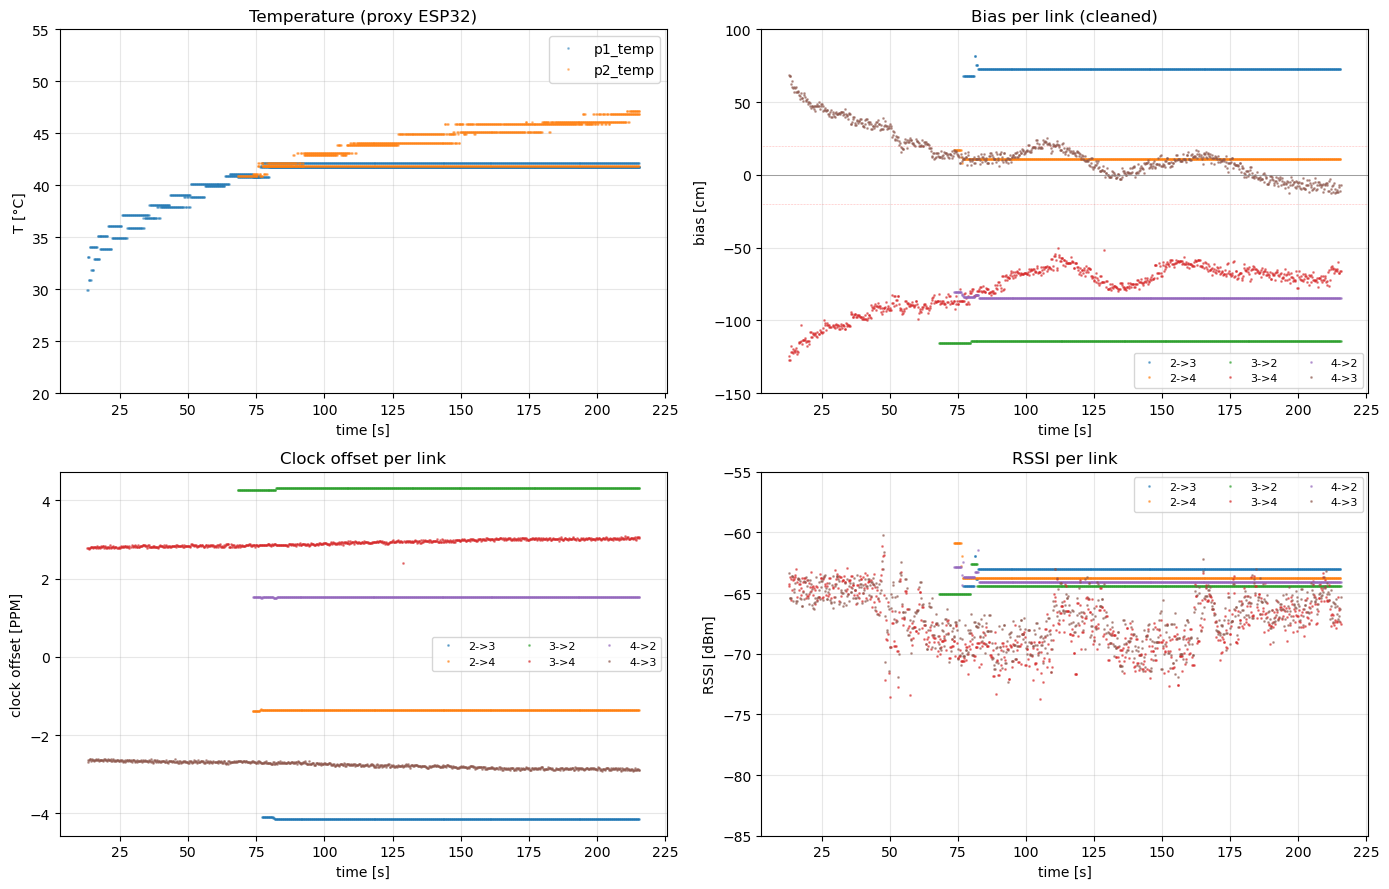

In [3]:
# ============================================================
# Gateway analysis — cleaned, CFO + proxy temperature
# ============================================================
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 320)
np.set_printoptions(precision=4, suppress=True)

# ------------------------------------------------------------
# 0. Load
# ------------------------------------------------------------
FILE = "third_test.csv"

rows = []
with open(FILE, "r") as f:
    for line in f:
        line = line.strip()
        if not line or line.startswith("#"):
            continue
        rows.append(line)

header = rows[0].split(",")
df = pd.DataFrame([r.split(",") for r in rows[1:]], columns=header)
for c in df.columns:
    df[c] = pd.to_numeric(df[c], errors="coerce")

print(f"Total beacon records: {len(df)}")

# ------------------------------------------------------------
# 1. STRICT outlier filter
# ------------------------------------------------------------
# Three independent criteria, applied jointly:
#   raw dist in [0.1, 50]      m  — physical envelope
#   clean dist in [-5, 15]      m  — post-correction must be sane
#   temperature in [15, 80]     °C — chip must be in range
#   ppm in [-100, +100]            — clock offset must be physical
UWB_RAW_MIN,   UWB_RAW_MAX   = 0.1,  50.0
UWB_CLEAN_MIN, UWB_CLEAN_MAX = -5.0, 15.0
TEMP_MIN,      TEMP_MAX      = 15.0, 80.0
PPM_MIN,       PPM_MAX       = -100.0, 100.0

link_records = []
rejected_count = {"raw_out": 0, "clean_out": 0,
                  "temp_out": 0, "ppm_out": 0, "ok": 0}

for _, row in df.iterrows():
    sender = int(row["senderId"])
    for slot in (1, 2):
        pid = int(row[f"p{slot}_id"])
        if pid == 0: continue
        raw   = row[f"p{slot}_raw"]
        clean = row[f"p{slot}_clean"]
        temp  = row[f"p{slot}_temp"]
        ppm   = row[f"p{slot}_ppm"]

        if abs(raw) < 1e-6: continue

        if not (UWB_RAW_MIN < raw < UWB_RAW_MAX):
            rejected_count["raw_out"] += 1; continue
        if not (UWB_CLEAN_MIN < clean < UWB_CLEAN_MAX):
            rejected_count["clean_out"] += 1; continue
        if not (TEMP_MIN < temp < TEMP_MAX):
            rejected_count["temp_out"] += 1; continue
        if not (PPM_MIN < ppm < PPM_MAX):
            rejected_count["ppm_out"] += 1; continue

        rejected_count["ok"] += 1
        link_records.append({
            "rx_ms":   row["rx_ms"],
            "sender":  sender,
            "peer":    pid,
            "frame":   int(row["frameId"]),
            "raw":     raw,
            "clean":   clean,
            "rssi":    row[f"p{slot}_rssi"],
            "fp":      row[f"p{slot}_fp"],
            "temp":    temp,
            "ppm":     ppm,
        })

print(f"\nOutlier rejection summary:")
for k, v in rejected_count.items():
    print(f"  {k:>12s}: {v}")

links = pd.DataFrame(link_records)
links["link"] = links["sender"].astype(str) + "->" + links["peer"].astype(str)
links["t_s"]  = links["rx_ms"] / 1000.0
print(f"\nTotal valid link records: {len(links)}")

GT_DIST = {
    "2->3": 2.000, "3->2": 2.000,
    "3->4": 2.000, "4->3": 2.000,
    "2->4": 2.828, "4->2": 2.828,
}

# ------------------------------------------------------------
# 2. Per-link summary after cleaning
# ------------------------------------------------------------
print("\n" + "=" * 96)
print(" [A] PER-LINK SUMMARY (cleaned)")
print("=" * 96)
print(f"{'link':>6s} | {'n':>4s} | {'raw_mean':>10s} | "
      f"{'clean_mean':>11s} | {'clean_std':>10s} | "
      f"{'bias_mean':>10s} | {'bias_std':>10s} | "
      f"{'ppm_mean':>10s}")
print("-" * 100)
for lk, grp in links.groupby("link"):
    if lk not in GT_DIST: continue
    gt = GT_DIST[lk]
    bias = (grp["clean"] - gt) * 100
    print(f"{lk:>6s} | {len(grp):>4d} | "
          f"{grp['raw'].mean():>+10.4f} | "
          f"{grp['clean'].mean():>+11.4f} | "
          f"{grp['clean'].std():>10.4f} | "
          f"{bias.mean():>+10.2f} | "
          f"{bias.std():>10.2f} | "
          f"{grp['ppm'].mean():>+10.3f}")

# ------------------------------------------------------------
# 3. Link asymmetry (cleaned)
# ------------------------------------------------------------
print("\n" + "=" * 96)
print(" [B] LINK ASYMMETRY (CLEANED)")
print("=" * 96)
bias_summary = {}
for lk, grp in links.groupby("link"):
    if lk not in GT_DIST: continue
    bias_summary[lk] = (grp["clean"].mean() - GT_DIST[lk]) * 100

print(f"  Previous test (without CFO):")
print(f"    2↔3 = 83 cm  |  3↔4 = 98 cm  |  2↔4 = 12 cm")
print(f"\n  Current test (with CFO):")
for a, b in [(2, 3), (3, 4), (2, 4)]:
    fk = f"{a}->{b}"; rk = f"{b}->{a}"
    if fk not in bias_summary or rk not in bias_summary: continue
    fb = bias_summary[fk]; rb = bias_summary[rk]
    print(f"    {a}↔{b}: fwd={fb:+.2f}, rev={rb:+.2f}, |Δ|={abs(fb-rb):.2f} cm")

# ------------------------------------------------------------
# 4. Bias evolution
# ------------------------------------------------------------
print("\n" + "=" * 96)
print(" [C] BIAS EVOLUTION (CLEANED)")
print("=" * 96)
for lk, grp in links.groupby("link"):
    if lk not in GT_DIST: continue
    if len(grp) < 20: continue
    t = grp["t_s"].values
    b = (grp["clean"].values - GT_DIST[lk]) * 100
    order = np.argsort(t)
    t = t[order]; b = b[order]
    n = len(b); q = n // 4
    w = [b[:q].mean(), b[q:2*q].mean(),
         b[2*q:3*q].mean(), b[3*q:].mean()]
    print(f"  {lk}: W1={w[0]:>+7.2f}  W2={w[1]:>+7.2f}  "
          f"W3={w[2]:>+7.2f}  W4={w[3]:>+7.2f}  "
          f"spread={max(w)-min(w):>6.2f} cm")

# ------------------------------------------------------------
# 5. PLOTS (cleaned)
# ------------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# (a) Temperature
ax = axes[0, 0]
for slot in (1, 2):
    tcol = f"p{slot}_temp"
    if tcol not in df.columns: continue
    sub = df[df[tcol] > 0]
    ax.plot(sub["rx_ms"] / 1000.0, sub[tcol],
            ".", ms=2, alpha=0.4, label=f"p{slot}_temp")
ax.set_xlabel("time [s]"); ax.set_ylabel("T [°C]")
ax.set_title("Temperature (proxy ESP32)")
ax.legend(); ax.grid(True, alpha=0.3)
ax.set_ylim(20, 55)

# (b) Bias per link
ax = axes[0, 1]
for lk, grp in links.groupby("link"):
    if lk not in GT_DIST: continue
    bias = (grp["clean"] - GT_DIST[lk]) * 100
    ax.plot(grp["t_s"], bias, ".", ms=2, alpha=0.5, label=lk)
ax.axhline(0, color="gray", lw=0.5)
ax.axhline(+20, color="red", ls=":", lw=0.4, alpha=0.5)
ax.axhline(-20, color="red", ls=":", lw=0.4, alpha=0.5)
ax.set_xlabel("time [s]"); ax.set_ylabel("bias [cm]")
ax.set_title("Bias per link (cleaned)")
ax.legend(fontsize=8, ncol=3); ax.grid(True, alpha=0.3)
ax.set_ylim(-150, +100)

# (c) PPM per link
ax = axes[1, 0]
for lk, grp in links.groupby("link"):
    ax.plot(grp["t_s"], grp["ppm"], ".", ms=2, alpha=0.5, label=lk)
ax.set_xlabel("time [s]"); ax.set_ylabel("clock offset [PPM]")
ax.set_title("Clock offset per link")
ax.legend(fontsize=8, ncol=3); ax.grid(True, alpha=0.3)

# (d) RSSI per link
ax = axes[1, 1]
for lk, grp in links.groupby("link"):
    ax.plot(grp["t_s"], grp["rssi"], ".", ms=2, alpha=0.5, label=lk)
ax.set_xlabel("time [s]"); ax.set_ylabel("RSSI [dBm]")
ax.set_title("RSSI per link")
ax.legend(fontsize=8, ncol=3); ax.grid(True, alpha=0.3)
ax.set_ylim(-85, -55)

plt.tight_layout()
plt.savefig("third_test_cleaned.png", dpi=120)
plt.show()

Total beacon records: 2528
Raw link records: 4005

 [A] BIAS COMPARISON: THREE CFO SCENARIOS
  link |    n |   with_cfo |     no_cfo |    inv_cfo |     best
--------------------------------------------------------------------------
  2->3 |  569 |     +72.85 |     -82.12 |    -237.09 |     with
  2->4 |  583 |     +10.89 |     -40.48 |     -91.85 |     with
  3->2 |  606 |    -114.21 |     +47.05 |    +208.31 |       no
  3->4 |  828 |     -68.89 |     +40.58 |    +150.06 |       no
  4->2 |  583 |     -84.48 |     -27.23 |     +30.01 |       no
  4->3 |  828 |     +14.87 |     -88.61 |    -192.09 |     with

 [B] ASYMMETRY COMPARISON
  Previous test (no CFO, n/a now):  2↔3 = 83 cm  |  3↔4 = 98 cm  |  2↔4 = 12 cm

  pair |   with_cfo |     no_cfo |    inv_cfo
----------------------------------------------------
2↔3 |     187.06 |     129.17 |     445.40
3↔4 |      83.76 |     129.19 |     342.15
2↔4 |      95.37 |      13.25 |     121.86

 [C] AGGREGATE ASYMMETRY (sum over 3 pairs)
  w

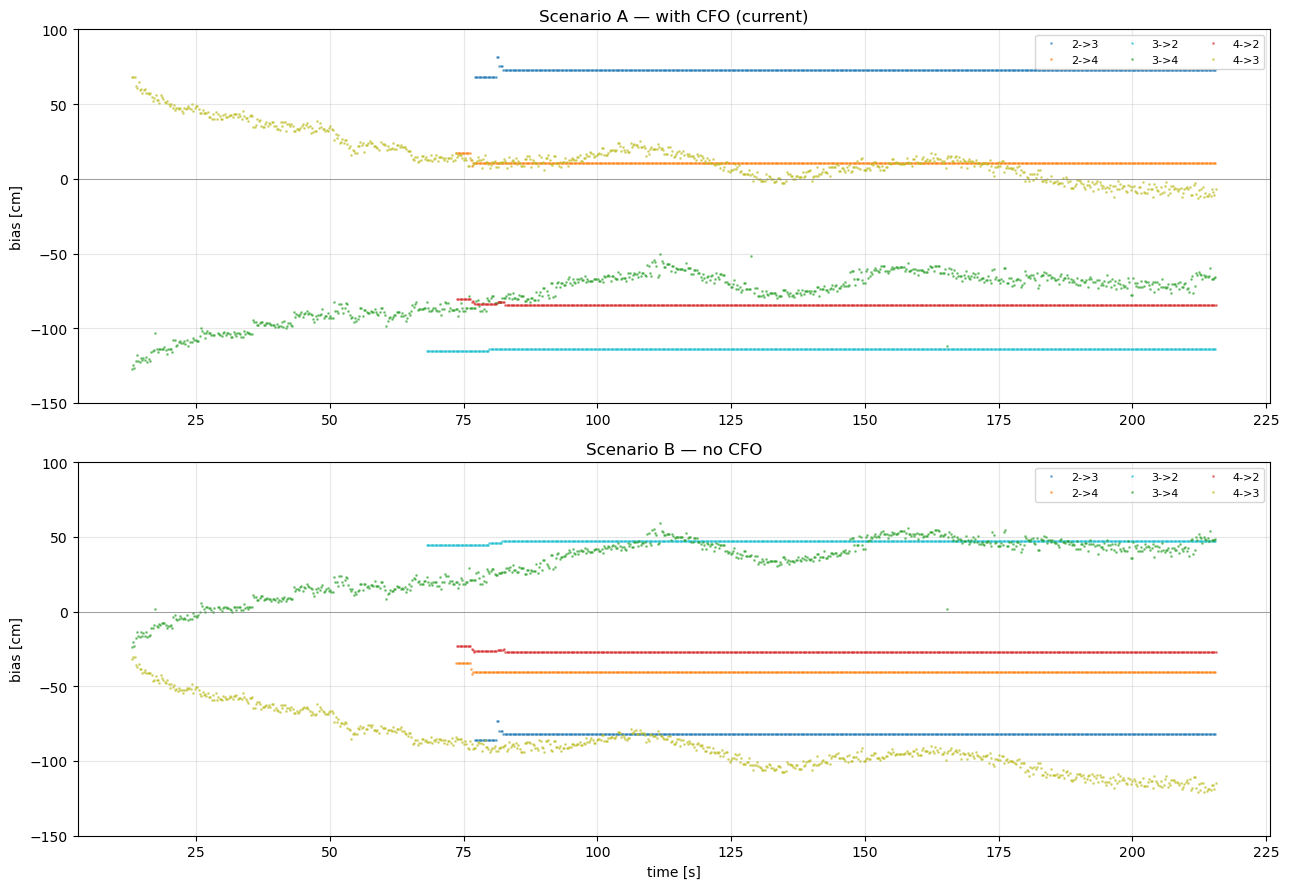

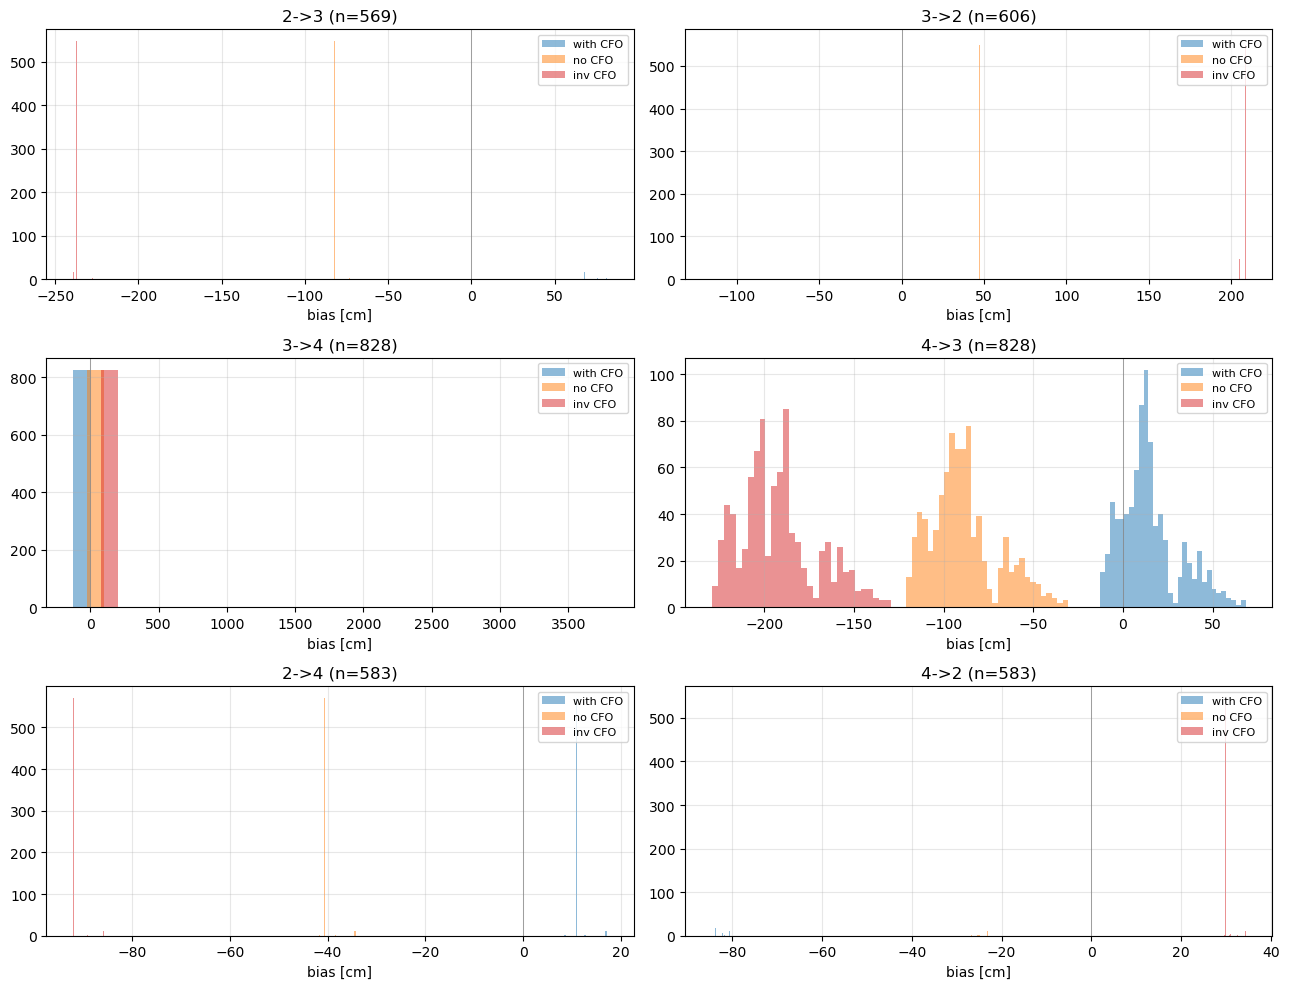

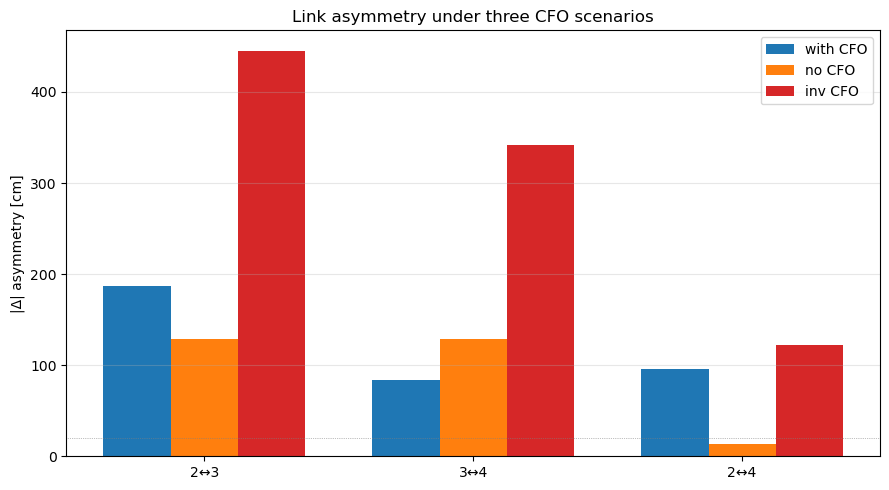

In [4]:
# ============================================================
# CFO scenario comparison: current / none / inverted
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 320)

# ------------------------------------------------------------
# 0. Load
# ------------------------------------------------------------
FILE = "third_test.csv"

rows = []
with open(FILE, "r") as f:
    for line in f:
        line = line.strip()
        if not line or line.startswith("#"):
            continue
        rows.append(line)

header = rows[0].split(",")
df = pd.DataFrame([r.split(",") for r in rows[1:]], columns=header)
for c in df.columns:
    df[c] = pd.to_numeric(df[c], errors="coerce")

print(f"Total beacon records: {len(df)}")

# ------------------------------------------------------------
# 1. Extract valid link records (no outlier filter yet)
# ------------------------------------------------------------
link_records = []
for _, row in df.iterrows():
    sender = int(row["senderId"])
    for slot in (1, 2):
        pid = int(row[f"p{slot}_id"])
        if pid == 0: continue
        raw   = row[f"p{slot}_raw"]
        clean = row[f"p{slot}_clean"]
        temp  = row[f"p{slot}_temp"]
        ppm   = row[f"p{slot}_ppm"]
        if abs(raw) < 1e-6: continue
        link_records.append({
            "rx_ms":   row["rx_ms"],
            "sender":  sender,
            "peer":    pid,
            "raw":     raw,
            "clean":   clean,
            "temp":    temp,
            "ppm":     ppm,
        })

raw_links = pd.DataFrame(link_records)
raw_links["t_s"]  = raw_links["rx_ms"] / 1000.0
raw_links["link"] = raw_links["sender"].astype(str) + "->" + raw_links["peer"].astype(str)

print(f"Raw link records: {len(raw_links)}")

# ------------------------------------------------------------
# 2. Reconstruct dist under three CFO scenarios
# ------------------------------------------------------------
# The stored `raw` is dist_with_cfo.
# Definitions:
#   dist_with_cfo = (tRound - tReply*(1+k)) / 2 * TU * c
#   dist_no_cfo   = (tRound - tReply)      / 2 * TU * c
#   dist_inv_cfo  = (tRound - tReply*(1-k)) / 2 * TU * c
#
# With k = ppm * 1e-6, tReply = 159,744,000 ticks:
#   TU * c = 15.650040e-12 s × 299792458 m/s = 4.6918e-3 m/tick
#   Coefficient = tReply/2 * TU * c = 0.3747 m per PPM
#
# Therefore:
#   dist_no_cfo  = dist_with_cfo + 0.3747 * ppm   [m]
#   dist_inv_cfo = dist_with_cfo + 0.7494 * ppm   [m]
#
# Add these as new columns:
K_NO  = 0.3747    # m per PPM
K_INV = 0.7494    # 2 × K_NO

raw_links["dist_no_cfo"]  = raw_links["raw"] + K_NO  * raw_links["ppm"]
raw_links["dist_inv_cfo"] = raw_links["raw"] + K_INV * raw_links["ppm"]

# We also need the "clean" version, but since BIAS_RAW and THERMAL are
# deterministic functions of (sender, peer, temp), the DIFFERENCE between
# scenarios is exactly the same as for raw. So:
#
#   clean_no_cfo  = clean + 0.3747 * ppm
#   clean_inv_cfo = clean + 0.7494 * ppm
#
raw_links["clean_no_cfo"]  = raw_links["clean"] + K_NO  * raw_links["ppm"]
raw_links["clean_inv_cfo"] = raw_links["clean"] + K_INV * raw_links["ppm"]

# ------------------------------------------------------------
# 3. Outlier filter (applied to clean values under each scenario)
# ------------------------------------------------------------
def filter_clean(d):
    """Keep only records where the requested 'clean' distance is physical."""
    mask = (d["clean"] > -5.0) & (d["clean"] < 50.0)
    return d[mask]

# Apply to primary clean
raw_links = filter_clean(raw_links)

# ------------------------------------------------------------
# 4. Ground truth
# ------------------------------------------------------------
GT_DIST = {
    "2->3": 2.000, "3->2": 2.000,
    "3->4": 2.000, "4->3": 2.000,
    "2->4": 2.828, "4->2": 2.828,
}

# ------------------------------------------------------------
# 5. Compute bias under each scenario
# ------------------------------------------------------------
print("\n" + "=" * 100)
print(" [A] BIAS COMPARISON: THREE CFO SCENARIOS")
print("=" * 100)
print(f"{'link':>6s} | {'n':>4s} | "
      f"{'with_cfo':>10s} | {'no_cfo':>10s} | {'inv_cfo':>10s} | "
      f"{'best':>8s}")
print("-" * 74)

scenario_results = {}
for lk, grp in raw_links.groupby("link"):
    if lk not in GT_DIST: continue
    gt = GT_DIST[lk]
    b_with = (grp["clean"]           - gt).mean() * 100
    b_no   = (grp["clean_no_cfo"]    - gt).mean() * 100
    b_inv  = (grp["clean_inv_cfo"]   - gt).mean() * 100

    # Determine "best" by smallest absolute value
    abs_vals = {"with": abs(b_with), "no": abs(b_no), "inv": abs(b_inv)}
    best = min(abs_vals, key=abs_vals.get)

    scenario_results[lk] = {
        "with": b_with,
        "no":   b_no,
        "inv":  b_inv,
    }

    print(f"{lk:>6s} | {len(grp):>4d} | "
          f"{b_with:>+10.2f} | {b_no:>+10.2f} | {b_inv:>+10.2f} | "
          f"{best:>8s}")

# ------------------------------------------------------------
# 6. Asymmetry under each scenario
# ------------------------------------------------------------
print("\n" + "=" * 100)
print(" [B] ASYMMETRY COMPARISON")
print("=" * 100)
print("  Previous test (no CFO, n/a now):  "
      "2↔3 = 83 cm  |  3↔4 = 98 cm  |  2↔4 = 12 cm")
print()
print(f"{'pair':>6s} | "
      f"{'with_cfo':>10s} | {'no_cfo':>10s} | {'inv_cfo':>10s}")
print("-" * 52)

for a, b in [(2, 3), (3, 4), (2, 4)]:
    fk = f"{a}->{b}"; rk = f"{b}->{a}"
    if fk not in scenario_results or rk not in scenario_results: continue
    for key, name in [("with", "with_cfo"), ("no", "no_cfo"), ("inv", "inv_cfo")]:
        pass
    with_a = abs(scenario_results[fk]["with"] - scenario_results[rk]["with"])
    no_a   = abs(scenario_results[fk]["no"]   - scenario_results[rk]["no"])
    inv_a  = abs(scenario_results[fk]["inv"]  - scenario_results[rk]["inv"])
    print(f"{a}↔{b} | {with_a:>10.2f} | {no_a:>10.2f} | {inv_a:>10.2f}")

# ------------------------------------------------------------
# 7. Aggregated asymmetry metric
# ------------------------------------------------------------
print("\n" + "=" * 100)
print(" [C] AGGREGATE ASYMMETRY (sum over 3 pairs)")
print("=" * 100)
tot_with = 0; tot_no = 0; tot_inv = 0
for a, b in [(2, 3), (3, 4), (2, 4)]:
    fk = f"{a}->{b}"; rk = f"{b}->{a}"
    if fk not in scenario_results or rk not in scenario_results: continue
    tot_with += abs(scenario_results[fk]["with"] - scenario_results[rk]["with"])
    tot_no   += abs(scenario_results[fk]["no"]   - scenario_results[rk]["no"])
    tot_inv  += abs(scenario_results[fk]["inv"]  - scenario_results[rk]["inv"])
print(f"  with_cfo:  {tot_with:>7.2f} cm")
print(f"  no_cfo:    {tot_no:>7.2f} cm   ← candidate fix")
print(f"  inv_cfo:   {tot_inv:>7.2f} cm   ← unlikely fix")

# ------------------------------------------------------------
# 8. PLOT 1 — Bias per link under three scenarios
# ------------------------------------------------------------
fig, axes = plt.subplots(2, 1, figsize=(13, 9))

colors = {"2->3": "tab:blue",   "3->2": "tab:cyan",
          "2->4": "tab:orange", "4->2": "tab:red",
          "3->4": "tab:green",  "4->3": "tab:olive"}

# (a) With CFO (current)
ax = axes[0]
for lk, grp in raw_links.groupby("link"):
    if lk not in GT_DIST: continue
    b = (grp["clean"] - GT_DIST[lk]) * 100
    ax.plot(grp["t_s"], b, ".", ms=2, alpha=0.5,
            color=colors.get(lk, "black"), label=lk)
ax.axhline(0, color="gray", lw=0.5)
ax.set_title("Scenario A — with CFO (current)")
ax.set_ylabel("bias [cm]"); ax.legend(fontsize=8, ncol=3)
ax.grid(True, alpha=0.3); ax.set_ylim(-150, +100)

# (b) No CFO
ax = axes[1]
for lk, grp in raw_links.groupby("link"):
    if lk not in GT_DIST: continue
    b = (grp["clean_no_cfo"] - GT_DIST[lk]) * 100
    ax.plot(grp["t_s"], b, ".", ms=2, alpha=0.5,
            color=colors.get(lk, "black"), label=lk)
ax.axhline(0, color="gray", lw=0.5)
ax.set_title("Scenario B — no CFO")
ax.set_xlabel("time [s]"); ax.set_ylabel("bias [cm]")
ax.legend(fontsize=8, ncol=3)
ax.grid(True, alpha=0.3); ax.set_ylim(-150, +100)

plt.tight_layout()
plt.savefig("cfo_scenarios_time.png", dpi=120)
plt.show()

# ------------------------------------------------------------
# 9. PLOT 2 — Bias histogram per scenario per link
# ------------------------------------------------------------
fig, axes = plt.subplots(3, 2, figsize=(13, 10))

pairs = [("2->3", 0, 0), ("3->2", 0, 1),
         ("3->4", 1, 0), ("4->3", 1, 1),
         ("2->4", 2, 0), ("4->2", 2, 1)]

for lk, r, c in pairs:
    ax = axes[r, c]
    grp = raw_links[raw_links["link"] == lk]
    if len(grp) == 0: continue
    gt = GT_DIST[lk]
    b_with = (grp["clean"]          - gt) * 100
    b_no   = (grp["clean_no_cfo"]   - gt) * 100
    b_inv  = (grp["clean_inv_cfo"]  - gt) * 100

    ax.hist(b_with, bins=30, alpha=0.5, label="with CFO", color="tab:blue")
    ax.hist(b_no,   bins=30, alpha=0.5, label="no CFO",   color="tab:orange")
    ax.hist(b_inv,  bins=30, alpha=0.5, label="inv CFO",  color="tab:red")
    ax.axvline(0, color="gray", lw=0.5)
    ax.set_title(f"{lk} (n={len(grp)})")
    ax.set_xlabel("bias [cm]")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("cfo_scenarios_hist.png", dpi=120)
plt.show()

# ------------------------------------------------------------
# 10. PLOT 3 — Asymmetry bar chart
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(9, 5))

pairs_list = [(2, 3), (3, 4), (2, 4)]
with_vals = []
no_vals = []
inv_vals = []
labels = []
for a, b in pairs_list:
    fk = f"{a}->{b}"; rk = f"{b}->{a}"
    if fk not in scenario_results or rk not in scenario_results: continue
    labels.append(f"{a}↔{b}")
    with_vals.append(abs(scenario_results[fk]["with"] - scenario_results[rk]["with"]))
    no_vals.append(  abs(scenario_results[fk]["no"]   - scenario_results[rk]["no"]))
    inv_vals.append( abs(scenario_results[fk]["inv"]  - scenario_results[rk]["inv"]))

x = np.arange(len(labels))
w = 0.25
ax.bar(x - w, with_vals, w, label="with CFO",  color="tab:blue")
ax.bar(x,     no_vals,   w, label="no CFO",    color="tab:orange")
ax.bar(x + w, inv_vals,  w, label="inv CFO",   color="tab:red")
ax.axhline(20, color="gray", ls=":", lw=0.5)
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylabel("|Δ| asymmetry [cm]")
ax.set_title("Link asymmetry under three CFO scenarios")
ax.legend(); ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.savefig("cfo_scenarios_asym.png", dpi=120)
plt.show()